In [1]:
import copy
import salvus.namespace as sn
import numpy as np
import matplotlib.pyplot as plt 

import sys
import importlib
from pathlib import Path
path_to_add = str(Path.cwd() / "tomography") 
if path_to_add not in sys.path:
    sys.path.append(path_to_add)

import my_code.utilities
importlib.reload(my_code.utilities)
from my_code.utilities import *
import salvus

import salvus.mesh.layered_meshing as lm
from datetime import datetime
import salvus.flow.simple_config as sc
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)

import xarray as xr

--> Server: 'https://l.mondaic.com/licensing_server', User: 'bristol.support', Group: 'UniversityOfBristol'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.33 seconds]


## Configuration, project and mesh

In [2]:
# ---- Salvus site --------------------------------------------------------
SITE_NAME = "isambard_oliver"
RANKS = 8

# ---- Physical parameters ------------------------------------------------
VP                = 5000.0
RHO               = 2600.0
THICKNESS           = 0.2   # m

alpha = 0.2  # thickness to wavelength ratio
f_c               = alpha * 25e3   # centre frequency [Hz]
CENTRAL_FREQUENCY = 2 * 25e3  # Hz




# ---- Domain -------------------------------------------------------------
x0, x1 = 0.0, 1.0
y0, y1 = 0.0, 1.0

# ---- Project ------------------------------------------------------------
PROJECT_DIR_WIN = '/home/b6as/oliverwfy.b6as/workspace/acoustic_model/Project'
DATA_DIR_WIN    = '/home/b6as/oliverwfy.b6as/workspace/acoustic_model/data'
IMAGE_DIR   = Path('/home/b6as/oliverwfy.b6as/workspace/acoustic_FWI_velocity_underwater/image')

Path(PROJECT_DIR_WIN).mkdir(parents=True, exist_ok=True)
Path(DATA_DIR_WIN).mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_NAME = f'acoustic_forward_single_pairs_alpha_{alpha}'
domain = sn.domain.dim2.BoxDomain(x0=x0, x1=x1, y0=y0, y1=y1)

p = sn.Project.from_domain(
    path=Path(PROJECT_DIR_WIN, PROJECT_NAME), domain=domain, load_if_exists=True
)

# ---- Mesh resolution ----------------------------------------------------
elements_per_wavelength = 3
model_order             = 4
reference_velocity      = 5000
number_of_wavelengths   = 2
reference_frequency     = CENTRAL_FREQUENCY * 2
free_surfaces           = ['y0', 'y1']

# ---- True (layered) model -----------------------------------------------
m_true = sn.layered_meshing.LayeredModel([
    sn.material.from_params(rho=RHO, vp=VP),
    sn.layered_meshing.interface.Hyperplane.at(0.6),
    sn.material.from_params(rho=RHO, vp=1.5 * VP),
    sn.layered_meshing.interface.Hyperplane.at(0.4),
    sn.material.from_params(rho=RHO, vp=VP),
])

# ---- Homogeneous starting model -----------------------------------------
m_homo = sn.material.from_params(rho=RHO, vp=VP)

ab_params = salvus.mesh.simple_mesh.basic_mesh.AbsorbingBoundaryParameters(
    free_surface=free_surfaces,
    number_of_wavelengths=number_of_wavelengths,
    reference_velocity=reference_velocity,
    reference_frequency=reference_frequency,
)

mesh_res = sn.MeshResolution(
    reference_frequency=reference_frequency,
    elements_per_wavelength=elements_per_wavelength,
    model_order=model_order,
)

mesh_homo = lm.mesh_from_domain(
    domain=domain,
    model=sn.layered_meshing.MeshingProtocol(m_homo, ab=ab_params),
    mesh_resolution=mesh_res,
)

mesh = lm.mesh_from_domain(
    domain=domain,
    model=sn.layered_meshing.MeshingProtocol(m_true, ab=ab_params),
    mesh_resolution=mesh_res,
)
mesh

Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-05-27 15:05:07,694] INFO: Loading project from /home/b6as/oliverwfy.b6as/workspace/acoustic_model/Project/acoustic_forward_single_pairs_alpha_0.2.


In [3]:
# # salvus project 
# p_salvus = sn.Project.from_domain(
#     path=Path(PROJECT_DIR_WIN, 'acoustic_forward_5paris_salvus'), domain=domain, load_if_exists=True
# )
# p_salvus.inversions.get_model("inversion_L2", 5)

In [4]:
# VP_elemental = elemental_nodal_to_elemental_field(mesh.element_nodal_fields['VP'], mesh)

# print("ENF shape      :", mesh.element_nodal_fields['VP'].shape)
# print("Elemental shape:", VP_elemental.shape)
# print(f"VP stats — min: {VP_elemental.min():.1f}  max: {VP_elemental.max():.1f}  mean: {VP_elemental.mean():.1f}")


# centroids = mesh.get_element_centroid()   # (nelem, 2)
# x_c, y_c = centroids[:, 0], centroids[:, 1]

# roi_elem = (x_c >= x0) & (x_c <= x1) & (y_c >= y0) & (y_c <= y1)

# x_r = x_c[roi_elem]
# y_r = y_c[roi_elem]
# vp_r = VP_elemental[roi_elem]

# # Reshape to 2-D grid
# xs = np.unique(x_r)
# ys = np.unique(y_r)
# nx, ny = len(xs), len(ys)

# idx = np.lexsort((x_r, y_r))          # sort by y then x
# VP_2d = vp_r[idx].reshape(ny, nx)
# X_2d  = x_r[idx].reshape(ny, nx)
# Y_2d  = y_r[idx].reshape(ny, nx)

# fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
# pm = ax.pcolormesh(X_2d, Y_2d, VP_2d, cmap='viridis', shading='nearest')
# plt.colorbar(pm, ax=ax, label='VP [m/s]')
# ax.set_xlabel('X [m]')
# ax.set_ylabel('Y [m]')
# ax.set_title(f'VP')
# ax.set_aspect('equal')
# plt.tight_layout()
# plt.show()

## Source / receiver setup

In [5]:
# event_single = 'single_pair'

# amplitude_ratio = 1e5
# s_loc = (0.5, 0.3)
# r_loc = [(0.5, 0.7)]

# receivers = [
#     sn.simple_config.receiver.cartesian.Point2D(
#         x=r[0], y=r[1], station_code=f"R{j+1}", fields=["phi"]
#     )
#     for j, r in enumerate(r_loc)
# ]
# source = sn.simple_config.source.cartesian.ScalarPoint2D(
#     x=s_loc[0], y=s_loc[1], f=amplitude_ratio
# )

# p.add_to_project(
#     sn.Event(event_name=event_single, sources=source, receivers=receivers)
# )

In [6]:
event = 'single_pairs'
amplitude_ratio = 1e3

s_loc = (0.5, 0.3)
r_loc = [(0.5, 0.7)]

# r_loc = [(x, 0.7) for x in np.linspace(0.2, 0.8, 5)]

receivers = [
    sn.simple_config.receiver.cartesian.Point2D(
        x=r[0], y=r[1], station_code=f"R{j+1}", fields=["phi"]
    )
    for j, r in enumerate(r_loc)
]
source = sn.simple_config.source.cartesian.ScalarPoint2D(
    x=s_loc[0], y=s_loc[1], f=amplitude_ratio
)
p.add_to_project(
    sn.Event(event_name=event, sources=source, receivers=receivers)
)

event_ls = [event]

[2026-05-27 15:05:15,302] INFO: An event with name 'single_pairs' and identical content already exists in the project. Nothing will be done.


## Simulation configurations

In [7]:
end_time               = 2e-4 * 1.75
start_time             = 0
sampling_rate_in_hertz = CENTRAL_FREQUENCY * 200
time_shift_in_seconds  = 1 / f_c

wavelet = sn.simple_config.stf.Ricker(
    center_frequency=f_c,
    time_shift_in_seconds=time_shift_in_seconds,
)

waveform_config = sn.WaveformSimulationConfiguration(
    start_time_in_seconds=start_time,
    end_time_in_seconds=end_time,
    time_step_in_seconds=1 / sampling_rate_in_hertz,
)

event_config = sn.EventConfiguration(
    wavelet=wavelet,
    waveform_simulation_configuration=waveform_config,
)

# Homogeneous (starting) model
p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        unstructured_mesh=mesh_homo,
        name='forward_simulation_homogeneous_model',
        event_configuration=event_config,
    ),
    overwrite=True,
)

# True (layered) model — used to generate observed data
p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        unstructured_mesh=mesh,
        name='forward_simulation_layred_model',
        event_configuration=event_config,
    ),
    overwrite=True,
)

p.viz.nb.simulation_setup(
    simulation_configuration='forward_simulation_layred_model', events=event
    )

[2026-05-27 15:05:15,474] INFO: Deleting existing `forward_simulation_homogeneous_model` entity of type `simulation_configuration` ...
[2026-05-27 15:05:15,610] INFO: Deleting existing `forward_simulation_layred_model` entity of type `simulation_configuration` ...


## Helper functions

In [8]:
def forward_simulation(simulation_name, events,
                       fields=None, sampling_interval_in_time_steps=10):
    if fields:
        p.simulations.launch(
            ranks_per_job=RANKS,
            site_name=SITE_NAME,
            events=events,
            simulation_configuration=simulation_name,
            extra_output_configuration={
                "volume_data": {
                    "sampling_interval_in_time_steps": sampling_interval_in_time_steps,
                    "fields": fields,
                },
            },
            delete_conflicting_previous_results=True,
        )
    else:
        p.simulations.launch(
            ranks_per_job=RANKS,
            site_name=SITE_NAME,
            events=events,
            simulation_configuration=simulation_name,
            delete_conflicting_previous_results=True,
        )

    p.simulations.query(block=True, verbosity=1)





def extract_data(simulation, events, receiver_field='phi', field=None):
    ed = p.waveforms.get(data_name=simulation, events=events)[0]
    data = ed.get_waveform_data_xarray(receiver_field=receiver_field)
    wavefield = None
    if field:
        wavefield = wavefield_output_to_xarray(
            ed.get_wavefield_output(output_type='volume', field=field),
            p.simulations.get_mesh(simulation).points,
        ).T
    return data, wavefield


def misfit_adjoint_source(u_obs, u, event=False, iteration=0):
    sampling_rate = u_obs.sampling_rate_in_hertz
    start_time    = u_obs.time[0]
    end_time      = u_obs.time[-1]

    diff   = u_obs - u
    misfit = 0.5 / sampling_rate * (diff ** 2).sum()
    f_adj  = np.flip(diff, axis=1) / sampling_rate

    event_adj        = None
    event_config_adj = None

    if event:
        rxs, srcs    = p.events.get(event).receivers, p.events.get(event).sources
        rxs_adj_loc  = [r.location for r in srcs]
        src_adj_loc  = [t.location for t in rxs]

        stf_adj_ls = [
            sc.stf.Custom.from_array(
                np.array(f_adj[i]),
                sampling_rate_in_hertz=sampling_rate_in_hertz,
                start_time_in_seconds=0.0,
            )
            for i in range(len(src_adj_loc))
        ]

        srcs_adj = [
            sn.simple_config.source.cartesian.ScalarPoint2D(x=tx[0], y=tx[1], f=1)
            for tx in src_adj_loc
        ]
        rxs_adj = [
            sn.simple_config.receiver.cartesian.Point2D(
                x=rx[0], y=rx[1],
                fields=['phi'],
                station_code=f"ite:{iteration}_adj_{_i:06d}",
            )
            for _i, rx in enumerate(rxs_adj_loc)
        ]

        event_adj = f'{event}_adjoint_{iteration}'
        p.add_to_project(sn.Event(event_name=event_adj, sources=srcs_adj, receivers=rxs_adj))

        event_config_adj = sn.EventConfiguration(
            wavelet=stf_adj_ls,
            waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
                start_time_in_seconds=start_time,
                end_time_in_seconds=end_time,
                time_step_in_seconds=1 / sampling_rate_in_hertz,
            ),
        )

    return misfit, f_adj, event_adj, event_config_adj


def adjoint_wavefield(p, event_adj, event_config_adj,
                      model_simulation_name='forward_simulation_homogeneous_model',
                      field='phi_t', iteration=0,
                      sampling_interval_in_time_steps=10):
    simulation_adj  = f"adjoint_{iteration}"
    mesh_current    = p.simulations.get_mesh(model_simulation_name)

    p.add_to_project(
        sn.UnstructuredMeshSimulationConfiguration(
            unstructured_mesh=mesh_current,
            name=simulation_adj,
            event_configuration=event_config_adj,
        ),
        overwrite=True,
    )

    p.simulations.launch(
        ranks_per_job=RANKS,
        site_name=SITE_NAME,
        events=event_adj,
        simulation_configuration=simulation_adj,
        extra_output_configuration={
            "volume_data": {
                "sampling_interval_in_time_steps": sampling_interval_in_time_steps,
                "fields": [field],
            },
        },
        delete_conflicting_previous_results=True,
    )
    p.simulations.query(block=True, verbosity=1)


    _, wavefield_adj = extract_data(
        simulation=simulation_adj,
        events=event_adj,
        receiver_field='phi',
        field=field,
    )
    return wavefield_adj


def compute_gradient(forward_wavefield, adjoint_wavefield):
    """
    Sensitivity kernel K_A = ∂J/∂A  (zero-lag cross-correlation):

        K_A(x) = Σ_t φ†_t(x, T-t) · φ_t(x, t) · Δt

    φ† is time-reversed before the inner product because the adjoint
    simulation runs forward in time (source = time-reversed residual).

    Parameters
    ----------
    forward_wavefield : xarray   φ_t  shape (nodes, T)
    adjoint_wavefield : xarray   φ†_t    shape (nodes, T_adj)

    Returns
    -------
    K_A : np.ndarray, shape (n_nodes,)   ∂J/∂A
    """
    fwd = forward_wavefield.values.squeeze()    # (nodes, T)
    adj = adjoint_wavefield.values.squeeze()    # (nodes, T_adj)

    t_coord = forward_wavefield.coords.get('t', forward_wavefield.coords.get('time'))
    t_fwd   = t_coord.values
    dt      = float(t_fwd[1] - t_fwd[0])

    # Interpolate adjoint onto forward time axis if sampling strides differ
    if adj.shape[-1] != fwd.shape[-1]:
        from scipy.interpolate import interp1d
        t_adj = adjoint_wavefield.coords.get('t', adjoint_wavefield.coords.get('time')).values
        adj   = interp1d(t_adj, adj, axis=-1, kind='linear',
                         bounds_error=False, fill_value=0.0)(t_fwd)
                         

    # Time-reverse φ† → φ†(T-t), then dot with φ_tt(t)
    adj_flipped = np.flip(adj, axis=-1)                          # φ†(x, T-t)
    return np.einsum('nt,nt->n', adj_flipped, fwd) * dt          # (n_nodes,)

## Run initial simulations

Simulate the **true (layered) model** to generate observed data, and the **homogeneous model** with φ_tt volume output as the FWI starting point.

In [9]:
t0 = datetime.now()
event = event

# True model → observed data
forward_simulation(
    simulation_name='forward_simulation_layred_model',
    events=event,
    fields=None,
)
# p.simulations.query(block=True)

# Homogeneous model → starting synthetic + φ_tt wavefield
forward_simulation(
    simulation_name='forward_simulation_homogeneous_model',
    events=event,
    fields=['phi_t'],
    sampling_interval_in_time_steps=10,
)
# p.simulations.query(block=True)

elapsed = (datetime.now() - t0).total_seconds()
print(f"Initial simulations done in {int(elapsed//60)}m {elapsed%60:.1f}s")

[2026-05-27 15:05:22,439] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2605271505521158_8d1f685e61@isambard_oliver


VBox()

[2026-05-27 15:05:45,610] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2605271505616134_75ba4c4f46@isambard_oliver


VBox()

Initial simulations done in 1m 4.4s


## Adjoint source, adjoint wavefield and sensitivity kernel (iteration 0)

In [10]:
# ── 1. Extract initial synthetic data and φ_tt wavefield ─────────────────
phi_homo, phi_t = extract_data(
    simulation='forward_simulation_homogeneous_model',
    events=event,
    receiver_field='phi',
    field='phi_t',
)

phi_obs, _ = extract_data(
    simulation='forward_simulation_layred_model',
    events=event,
    receiver_field='phi',
    field=None,
)

# ── 2. Adjoint source ─────────────────────────────────────────────────────
misfit, f_adj, event_adj, event_config_adj = misfit_adjoint_source(
    phi_obs, phi_homo, event=event, iteration=0,
)
print(f"L2 Misfit (iteration 0): {float(misfit):.6e}")

# ── 3. Adjoint wavefield φ† ───────────────────────────────────────────────
phi_t_adj = adjoint_wavefield(
    p, event_adj, event_config_adj,
    model_simulation_name='forward_simulation_homogeneous_model',
    field='phi_t',
    iteration=0,
    sampling_interval_in_time_steps=10,
)

# ── 4. Mesh, node coordinates and VP nodal field ─────────────────────────
mesh_viz = p.simulations.get_mesh('forward_simulation_homogeneous_model')
x, y     = mesh_viz.points[:, 0], mesh_viz.points[:, 1]

# ── 5. Sensitivity kernel ∂J/∂ln(VP) — full mesh, then extract ROI ───────
ROI = (0.0, 1.0, 0.4, 0.6)                          # (x0, x1, y0, y1)
K_A = compute_gradient(phi_t, phi_t_adj)              # shape (nodes,) ∂J/∂A
K_A = np.where(np.isfinite(K_A), K_A, 0.0)

vp_nodal = elemental_nodal_to_nodal_field(
    mesh_viz.element_nodal_fields['VP'], mesh_viz.connectivity
)

# Chain rule: A = 1/VP²  →  ∂J/∂ln(VP) = K_A · (−2/VP²)
K_VP = K_A * (-2.0 / vp_nodal**2)                   # shape (nodes,) ∂J/∂ln(VP)

x0, x1, y0, y1 = ROI
roi_mask = (x >= x0) & (x <= x1) & (y >= y0) & (y <= y1)
K_roi    = K_VP[roi_mask]
x_roi    = x[roi_mask]
y_roi    = y[roi_mask]

# ── 6. Prepare arrays ─────────────────────────────────────────────────────
time_wf    = phi_homo.time.values

fwd = phi_t.values.squeeze()
adj = phi_t_adj.values.squeeze()

t_fwd = phi_t.coords.get('t', phi_t.coords.get('time')).values
t_adj = phi_t_adj.coords.get('t', phi_t_adj.coords.get('time')).values
if adj.shape[-1] != fwd.shape[-1]:
    from scipy.interpolate import interp1d
    adj = interp1d(t_adj, adj, axis=-1, kind='linear',
                   bounds_error=False, fill_value=0.0)(t_fwd)

adj_flipped = np.flip(adj, axis=-1)

T         = fwd.shape[-1]
dt        = float(t_fwd[1] - t_fwd[0])
t_indices = [T // 4, T // 2, 3 * T // 4]

def snap_clim(arr):
    v = np.percentile(np.abs(arr), 98)
    return dict(vmin=-v, vmax=v)

def normalize(arr):
    """Normalise to [-1, 1]."""
    m = np.nanmax(np.abs(arr))
    return arr / m if m > 0 else arr

# ── Shared grid and helper for ellipse contour overlays ───────────────────
_xg, _yg = np.linspace(0, 1, 400), np.linspace(0, 1, 400)
_Xg, _Yg = np.meshgrid(_xg, _yg)

width_3dB = envelope_3dB_width(phi_homo[0], time_wf, plot=False)['width'] / 2

# First Fresnel zone: 2a = d_direct + λ/2  →  a = (d_direct + VP * width_3dB) / 2
_d_sr  = np.sqrt((s_loc[0] - r_loc[0][0])**2 + (s_loc[1] - r_loc[0][1])**2)
_a_ell = (_d_sr + VP * width_3dB) / 2   # semi-major axis of coverage ellipse [m]


Finding enclosing elements (pass 1 of auto):   0%|          | 0/71577 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/17 [00:00<?, ?it/s]

L2 Misfit (iteration 0): 3.333337e+05
[2026-05-27 15:06:29,879] INFO: Submitting job ...
Uploading 2 files...

🚀  Submitted job_2605271506886687_0f24704aee@isambard_oliver


VBox()

Finding enclosing elements (pass 1 of auto):   0%|          | 0/71577 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/17 [00:00<?, ?it/s]

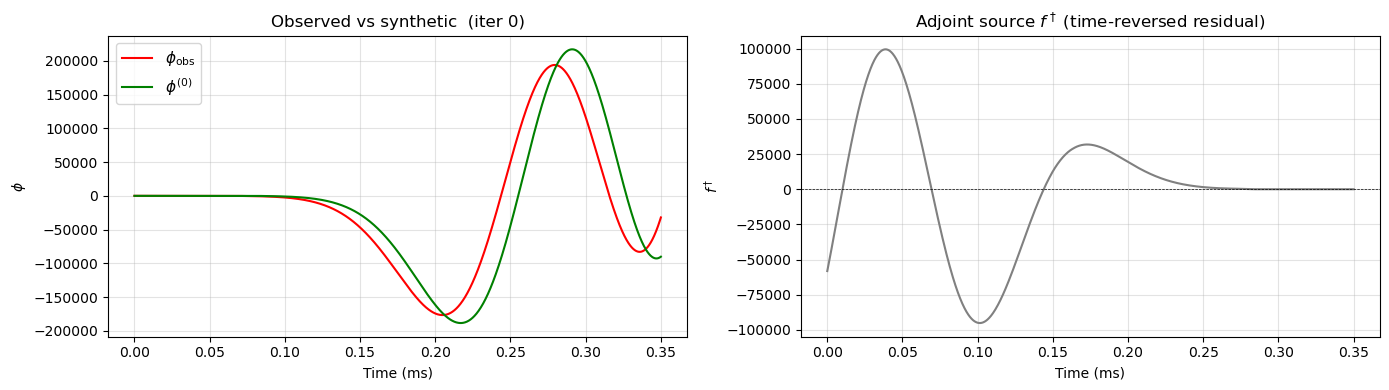

KeyboardInterrupt: 

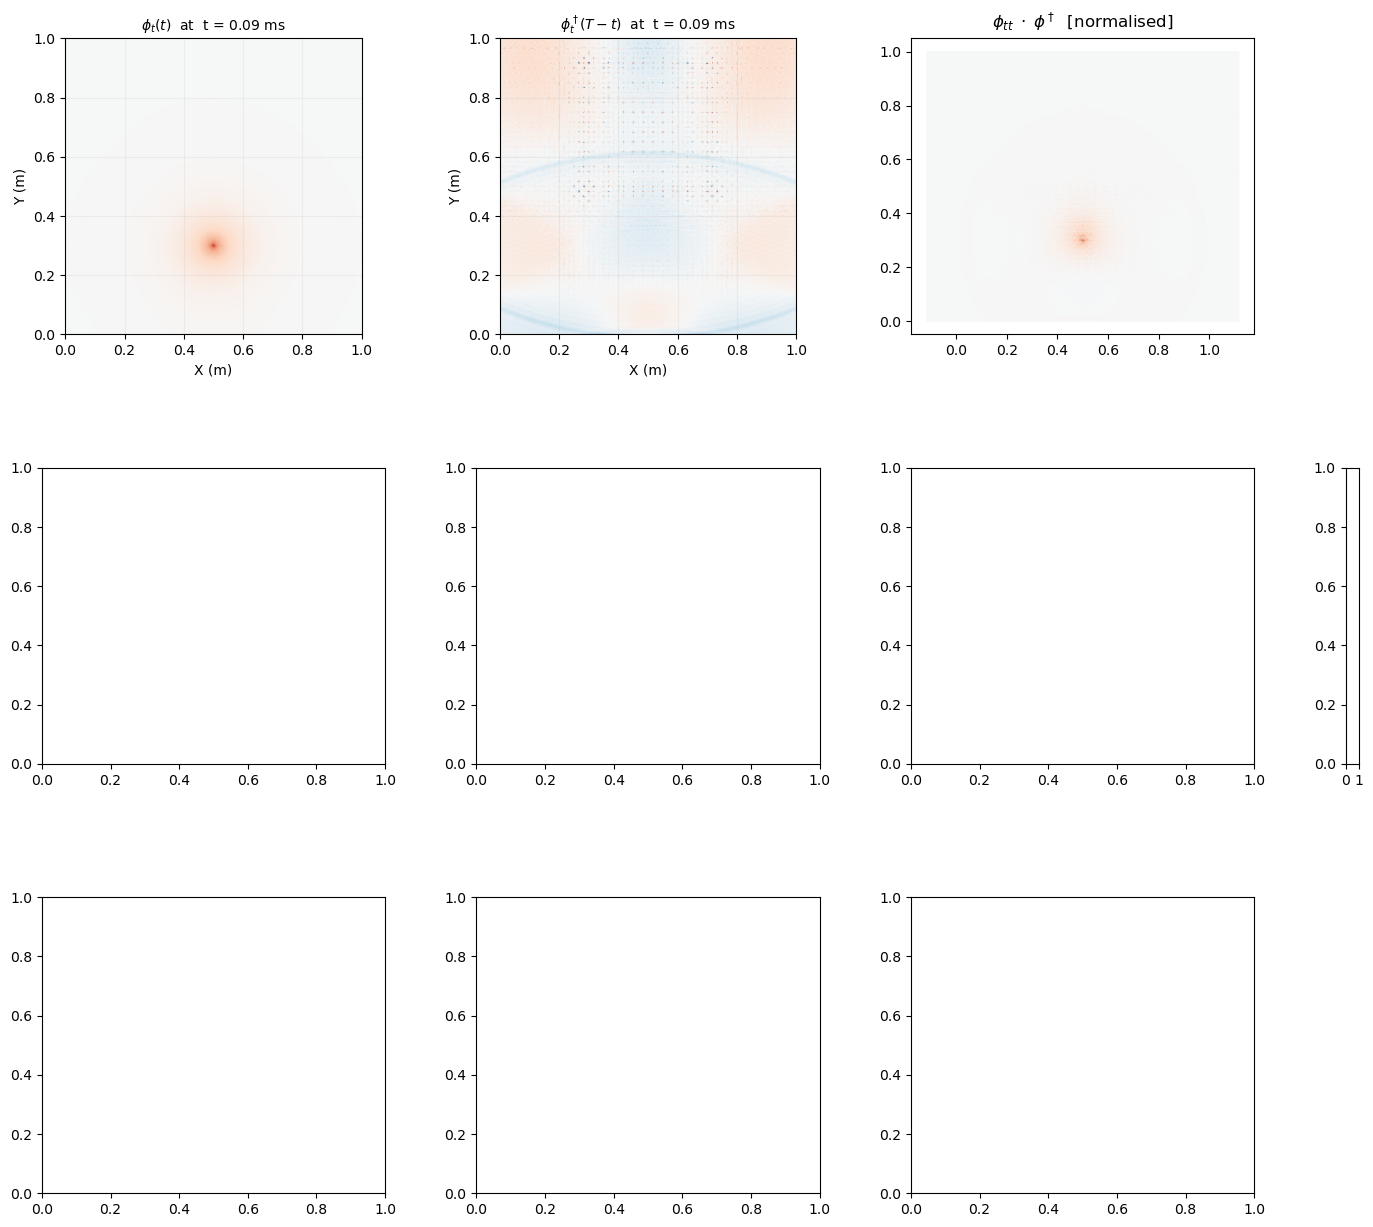

In [11]:

def _add_ellipse_overlay(ax, s_locs, r_locs, a, label=True):
    """Draw source-receiver ellipse contours and scatter source/receiver markers."""
    from matplotlib.lines import Line2D
    for s in s_locs:
        for r in r_locs:
            _d1 = np.sqrt((_Xg - s[0])**2 + (_Yg - s[1])**2)
            _d2 = np.sqrt((_Xg - r[0])**2 + (_Yg - r[1])**2)
            ax.contour(_Xg, _Yg, _d1 + _d2, levels=[2 * a],
                       colors='white', linewidths=1.5, linestyles='dashed', alpha=0.85)
    if label:
        ax.scatter([s[0] for s in s_locs], [s[1] for s in s_locs],
                   color='red',  s=60, zorder=5, label='Source')
        ax.scatter([r[0] for r in r_locs], [r[1] for r in r_locs],
                   color='lime', s=60, zorder=5, label='Receiver')
        ellipse_proxy = Line2D([0], [0], color='white', linewidth=1.5,
                               linestyle='dashed', label='Sensitivity region')
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles + [ellipse_proxy], labels=labels + ['Sensitivity region'],
                  fontsize=8, loc='upper right',
                  facecolor='dimgray', labelcolor='white', edgecolor='white')


def plot_fwi_diagnostics(it, phi_obs, phi_syn, f_adj, phi_t, phi_t_adj,
                          K_VP, K_roi, x, y, x_roi, y_roi,
                          x0_roi, x1_roi, y0_roi, y1_roi,
                          s_loc, r_loc, a_ell, save=True):
    """Plot 4 FWI diagnostic figures for iteration `it` and optionally save them."""
    from matplotlib.lines import Line2D
    from matplotlib.gridspec import GridSpec

    time_wf = phi_obs.time.values

    # ── Figure 1: waveforms + adjoint source ─────────────────────────────
    fig1, axs = plt.subplots(1, 2, figsize=(14, 4), dpi=100)
    axs[0].plot(time_wf * 1e3, np.array(phi_obs[0]), color='red',   lw=1.5, label=r'$\phi_\mathrm{obs}$')
    axs[0].plot(time_wf * 1e3, np.array(phi_syn[0]), color='green', lw=1.5, label=rf'$\phi^{{({it})}}$')
    axs[0].legend(fontsize=11)
    axs[0].set_xlabel('Time (ms)')
    axs[0].set_ylabel(r'$\phi$')
    axs[0].set_title(f'Observed vs synthetic  (iter {it})')
    axs[0].grid(alpha=0.35)
    axs[1].plot(time_wf * 1e3, np.array(-f_adj[0])*sampling_rate_in_hertz, color='gray', lw=1.5)
    axs[1].axhline(0, color='k', lw=0.5, ls='--')
    axs[1].set_xlabel('Time (ms)')
    axs[1].set_ylabel(r'$f^\dagger$')
    axs[1].set_title(r'Adjoint source $f^\dagger$ (time-reversed residual)')
    axs[1].grid(alpha=0.35)
    plt.tight_layout()
    if save:
        plt.savefig(IMAGE_DIR / f'iter_{it:03d}_adjoint_source_alpha_{alpha}.png')
    plt.show()

    # ── Figure 2: wavefield snapshots ────────────────────────────────────
    fwd = phi_t.values.squeeze()
    adj = phi_t_adj.values.squeeze()
    t_fwd = phi_t.coords.get('t', phi_t.coords.get('time')).values
    t_adj = phi_t_adj.coords.get('t', phi_t_adj.coords.get('time')).values
    if adj.shape[-1] != fwd.shape[-1]:
        from scipy.interpolate import interp1d
        adj = interp1d(t_adj, adj, axis=-1, kind='linear',
                       bounds_error=False, fill_value=0.0)(t_fwd)
    adj_flipped = np.flip(adj, axis=-1)
    T = fwd.shape[-1]
    t_indices = [T // 4, T // 2, 3 * T // 4]

    fig2 = plt.figure(figsize=(17, 15), dpi=100)
    gs = GridSpec(3, 4, figure=fig2, width_ratios=[1, 1, 1, 0.04],
                  hspace=0.45, wspace=0.35)
    axes2 = [[fig2.add_subplot(gs[r, c]) for c in range(3)] for r in range(3)]
    cax   = fig2.add_subplot(gs[1, 3])
    col_titles = [r'$\phi_{tt}(x,\,t)$  [normalised]',
                  r'$\phi^\dagger(x,\,T{-}t)$  [normalised]',
                  r'$\phi_{tt}\;\cdot\;\phi^\dagger$  [normalised]']
    for col, title in enumerate(col_titles):
        axes2[0][col].set_title(title, fontsize=12, pad=8)
    tp_last = None
    for row, ti in enumerate(t_indices):
        t_ms = t_fwd[ti] * 1e3
        s_fwd  = normalize(fwd[:, ti])
        s_adj  = normalize(adj_flipped[:, ti])
        s_prod = normalize(s_fwd * s_adj)
        for col, (snap, lbl) in enumerate([(s_fwd,  r'$\phi_{t} (t)$'),
                                            (s_adj,  r'$\phi^\dagger_{t} (T-t)$'),
                                            (s_prod, r'$\phi_{t} (t) * \phi^\dagger_{t} (T-t)$')]):
            ax = axes2[row][col]
            tp = ax.tripcolor(x, y, snap, cmap='RdBu', shading='gouraud', vmin=-1, vmax=1)
            ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
            ax.set_title(f'{lbl}  at  t = {t_ms:.2f} ms', fontsize=10)
            ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal'); ax.grid(alpha=0.15)
            if row == 1 and col == 2:
                tp_last = tp
    fig2.colorbar(tp_last, cax=cax, label='normalised amplitude')
    if save:
        plt.savefig(IMAGE_DIR / f'iter_{it:03d}_sensitivity_kernel_intermediate_alpha_{alpha}.png')
    plt.show()

    # ── Figure 3: full sensitivity kernel ────────────────────────────────
    fig3, ax_K = plt.subplots(figsize=(8, 6), dpi=100)
    _K_VP_max = np.max(np.abs(K_VP))
    tp = ax_K.tripcolor(x, y, K_VP, cmap='RdBu', shading='gouraud',
                        vmin=-_K_VP_max, vmax=_K_VP_max)
    plt.colorbar(tp, ax=ax_K, label=r'$\partial J/\partial \ln V_P$')
    _add_ellipse_overlay(ax_K, [s_loc], r_loc, a_ell)
    ax_K.set_xlabel('X (m)'); ax_K.set_ylabel('Y (m)')
    ax_K.set_title(rf'$K_{{VP}}$  —  full domain  (iter {it})', fontsize=12)
    ax_K.set_xlim(0, 1); ax_K.set_ylim(0, 1); ax_K.set_aspect('equal'); ax_K.grid(alpha=0.15)
    plt.tight_layout()
    if save:
        plt.savefig(IMAGE_DIR / f'iter_{it:03d}_sensitivity_kernel_full_alpha_{alpha}.png')
    plt.show()

    # ── Figure 4: ROI sensitivity kernel with ellipse mask ───────────────
    _d1 = np.sqrt((x_roi - s_loc[0])**2 + (y_roi - s_loc[1])**2)
    _d2 = np.sqrt((x_roi - r_loc[0][0])**2 + (y_roi - r_loc[0][1])**2)
    K_roi_masked = np.where((_d1 + _d2) <= 2 * a_ell, K_roi, 0.0)
    _K_roi_max = np.max(np.abs(K_roi_masked))
    fig4, ax_2d = plt.subplots(figsize=(8, 6), dpi=100)
    tp = ax_2d.tripcolor(x_roi, y_roi, K_roi_masked,
                         cmap='RdBu', shading='gouraud', vmin=-_K_roi_max, vmax=_K_roi_max)
    plt.colorbar(tp, ax=ax_2d, label=r'$\partial J/\partial \ln V_P$')
    _add_ellipse_overlay(ax_2d, [s_loc], r_loc, a_ell, label=False)
    _ellipse_proxy = Line2D([0], [0], color='white', linewidth=1.5,
                            linestyle='dashed', label='Sensitivity region')
    ax_2d.legend(handles=[_ellipse_proxy], fontsize=8, loc='upper right',
                 facecolor='dimgray', labelcolor='white', edgecolor='white')
    ax_2d.set_xlabel('X (m)'); ax_2d.set_ylabel('Y (m)')
    ax_2d.set_title(
        f'$K_{{VP}}$  in ROI  [{x0_roi}, {x1_roi}] × [{y0_roi}, {y1_roi}]  (iter {it})',
        fontsize=12,
    )
    ax_2d.set_xlim(x0_roi, x1_roi); ax_2d.set_ylim(y0_roi, y1_roi)
    ax_2d.set_aspect('equal'); ax_2d.grid(alpha=0.15)
    plt.tight_layout()
    if save:
        plt.savefig(IMAGE_DIR / f'iter_{it:03d}_sensitivity_kernel_roi_alpha_{alpha}.png')
    plt.show()


# ── Call for iteration 0 ──────────────────────────────────────────────────
plot_fwi_diagnostics(
    it=0,
    phi_obs=phi_obs, phi_syn=phi_homo, f_adj=f_adj,
    phi_t=phi_t, phi_t_adj=phi_t_adj,
    K_VP=K_VP, K_roi=K_roi,
    x=x, y=y, x_roi=x_roi, y_roi=y_roi,
    x0_roi=x0, x1_roi=x1, y0_roi=y0, y1_roi=y1,
    s_loc=s_loc, r_loc=r_loc, a_ell=_a_ell,
)


In [ ]:
# da = salvus.opt.misfits.l2_misfit.l2_misfit_and_adjoint_source(data_array_synthetic=phi_homo, data_array_observed=phi_obs, event=event_5p)
# misfits = da.misfits
# adjoint_source = da.adjoint_sources



# import time
# # compare sensitivity kernel with Salvus's built-in gradient computation
# p.add_to_project(
#     sn.MisfitConfiguration(
#         name="L2",
#         observed_data="forward_simulation_layred_model",
#         misfit_function="L2",
#         receiver_field=f'phi',
#     )
# )


# while not p.actions.inversion.compute_misfits(
#     simulation_configuration="forward_simulation_homogeneous_model", 
#     misfit_configuration="L2", 
#     events=event,
#     site_name=SITE_NAME,
#     ranks_per_job = 4
# ): time.sleep(10.0)


# while not p.actions.inversion.compute_gradients(
#     simulation_configuration="forward_simulation_homogeneous_model",
#     misfit_configuration="L2",
#     wavefield_compression=sn.WavefieldCompression(
#         forward_wavefield_sampling_interval=10
#     ),
#     events=event,
#     site_name=SITE_NAME,
#     ranks_per_job=4,
# ): time.sleep(10.0)



# p.viz.nb.gradients(
#     simulation_configuration="forward_simulation_homogeneous_model",
#     misfit_configuration="L2",
#     wavefield_compression=sn.WavefieldCompression(
#         forward_wavefield_sampling_interval=10
#     ),
#     events=event,
# )

In [ ]:
# ── Outer-scope setup ────────────────────────────────────────────────────
VP_MIN, VP_MAX    = VP * 0.5, VP * 2.0   # VP bounds [m/s]
SAMPLING_INTERVAL = 10

obs_simulation  = 'forward_simulation_layred_model'
init_simulation = 'forward_simulation_homogeneous_model'

base_mesh = copy.deepcopy(p.simulations.get_mesh(init_simulation))

phi_obs, _ = extract_data(
    simulation=obs_simulation, events=event, receiver_field='phi', field=None,
)

event_config_fwd = sn.EventConfiguration(
    wavelet=wavelet,
    waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
        start_time_in_seconds=0,
        end_time_in_seconds=end_time,
        time_step_in_seconds=1 / sampling_rate_in_hertz,
    ),
)

# nodal ROI mask — one entry per global node
_x, _y  = base_mesh.points[:, 0], base_mesh.points[:, 1]
x0_roi, x1_roi, y0_roi, y1_roi = ROI
roi_mask = (_x >= x0_roi) & (_x <= x1_roi) & (_y >= y0_roi) & (_y <= y1_roi)

# ── Ellipse sensitivity mask for ROI nodes (first Fresnel zone) ───────────
# Computed once — mesh, source, and receiver are fixed across all iterations.
_x_roi, _y_roi = _x[roi_mask], _y[roi_mask]
_d_sr_fwi = np.sqrt((s_loc[0] - r_loc[0][0])**2 + (s_loc[1] - r_loc[0][1])**2)

width_3dB = envelope_3dB_width(phi_homo[0], time_wf, plot=False)['width'] / 2
_a_fwi    = (_d_sr_fwi + VP * width_3dB) / 2   # first Fresnel zone semi-major axis
_ellipse_roi = np.zeros(roi_mask.sum(), dtype=bool)
for _s in [s_loc]:
    for _r in r_loc:
        _d1 = np.sqrt((_x_roi - _s[0])**2 + (_y_roi - _s[1])**2)
        _d2 = np.sqrt((_x_roi - _r[0])**2 + (_y_roi - _r[1])**2)
        _ellipse_roi |= (_d1 + _d2) <= 2 * _a_fwi
print(f"Ellipse mask: {_ellipse_roi.sum()} / {roi_mask.sum()} ROI nodes inside Fresnel zone")

# Pre-compute background nodal VP once (avoids repeated averaging)
_vp_bg_nodal = elemental_nodal_to_nodal_field(
    base_mesh.element_nodal_fields['VP'], base_mesh.connectivity
).copy()

# Pre-compute rounded y-coordinates for fast per-level grouping
_y_round_full = np.round(_y, decimals=8)
_y_round_roi  = np.round(_y[roi_mask], decimals=8)

_fwi_iter  = [0]
_fwi_ls    = [0]
_diag_cache = {}   # populated by objective(); read by L-BFGS loop for plotting


def _average_vp_in_x(vp_nodal):
    """Return vp_nodal with VP replaced by its x-average at every y-level.

    Enforces the layered-medium prior v(y): all nodes sharing the same
    depth receive the mean VP of that depth slice.
    """
    out = vp_nodal.copy()
    for yv in np.unique(_y_round_full):
        mask = _y_round_full == yv
        out[mask] = vp_nodal[mask].mean()
    return out


# ── Objective function ────────────────────────────────────────────────────
def objective(m_flat):
    """
    FWI objective — model parameter is ln(VP).

    Parameters
    ----------
    m_flat : np.ndarray, shape (n_roi_nodes,)
        Model vector: ln(VP) at each ROI node.

    Returns
    -------
    misfit : float
    grad   : np.ndarray, shape (n_roi_nodes,)   ∂J/∂ln(VP), zeroed outside Fresnel zone
    """
    it      = _fwi_iter[0]
    ls      = _fwi_ls[0]
    _fwi_ls[0] += 1
    sim_name = f'fwi_{it:03d}_grad' if ls == 0 else f'fwi_{it:03d}_ls_{ls}'

    # ── 1. Decode ln(VP) → VP, enforce v(y) by x-averaging ───────────────
    vp_roi   = np.clip(np.exp(m_flat), VP_MIN, VP_MAX)
    vp_nodal = _vp_bg_nodal.copy()
    vp_nodal[roi_mask] = vp_roi

    # Average VP in x at each y-level so the mesh always represents v(y)
    vp_nodal = _average_vp_in_x(vp_nodal)
    vp_roi   = vp_nodal[roi_mask]   # update to reflect averaged values

    mesh_it = copy.deepcopy(base_mesh)
    new_enf = vp_nodal[mesh_it.connectivity]          # (n_elem, n_nodes_per_elem)
    mesh_it.attach_field("VP", new_enf)
    vp_check = elemental_nodal_to_nodal_field(
        mesh_it.element_nodal_fields['VP'], mesh_it.connectivity
    )
    print(f'  [obj] VP(y) in ROI: mean={vp_roi.mean():.1f}  '
          f'range=[{vp_roi.min():.0f}, {vp_roi.max():.0f}]'
          f'  | mesh check: {vp_check[roi_mask].mean():.1f}')

    # ── Debug: v(y) profile + 2-D VP field ────────────────────────────────
    _y_unique   = np.unique(_y_round_full)
    _vp_profile = np.array([vp_nodal[_y_round_full == yv].mean() for yv in _y_unique])
    fig_vp, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
    tp_vp = axes[0].tripcolor(
        base_mesh.points[:, 0], base_mesh.points[:, 1],
        vp_nodal, cmap="RdBu_r", shading="gouraud",
    )
    plt.colorbar(tp_vp, ax=axes[0], label="VP  [m/s]")
    axes[0].set_xlabel("X (m)"); axes[0].set_ylabel("Y (m)")
    axes[0].set_title(rf"VP field — iter {it}  ls {ls}", fontsize=12)
    axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1); axes[0].set_aspect("equal")
    axes[0].grid(alpha=0.15)
    axes[1].plot(_vp_profile, _y_unique, "b-o", markersize=3, linewidth=1.5)
    axes[1].set_xlabel("VP  [m/s]"); axes[1].set_ylabel("Y (m)")
    axes[1].set_title(rf"v(y) profile — iter {it}  ls {ls}", fontsize=12)
    axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # ── 2. Register and run forward simulation ─────────────────────────────
    p.add_to_project(
        sn.UnstructuredMeshSimulationConfiguration(
            unstructured_mesh=mesh_it,
            name=sim_name,
            event_configuration=event_config_fwd,
        ),
        overwrite=True,
    )
    _stored = p.simulations.get_mesh(sim_name)
    _stored_vp = elemental_nodal_to_nodal_field(
        _stored.element_nodal_fields['VP'], _stored.connectivity
    )
    print(f'  [stored mesh] VP in ROI: mean={_stored_vp[roi_mask].mean():.1f}  '
          f'range=[{_stored_vp[roi_mask].min():.0f}, {_stored_vp[roi_mask].max():.0f}]')
    forward_simulation(sim_name, event,
                       fields=['phi_t'],
                       sampling_interval_in_time_steps=SAMPLING_INTERVAL)

    phi_syn, phi_t_it = extract_data(
        sim_name, event, receiver_field='phi', field='phi_t',
    )

    # ── 3. Misfit + adjoint source ─────────────────────────────────────────
    misfit, f_adj_wf, event_adj, event_config_adj = misfit_adjoint_source(
        phi_obs, phi_syn, event=event, iteration=sim_name,
    )

    # ── 4. Adjoint simulation ──────────────────────────────────────────────
    phi_adj_it = adjoint_wavefield(
        p, event_adj, event_config_adj,
        model_simulation_name=sim_name,
        field='phi_t', iteration=sim_name,
        sampling_interval_in_time_steps=SAMPLING_INTERVAL,
    )

    # ── 5. Gradient ∂J/∂ln(VP) via chain rule ─────────────────────────────
    # A = 1/VP²  →  ∂A/∂VP = −2/VP³
    # ∂J/∂ln(VP) = VP · ∂J/∂VP = VP · K_A · (−2/VP³) = K_A · (−2/VP²)
    K_A     = compute_gradient(phi_t_it, phi_adj_it)   # ∂J/∂A, shape (n_nodes,)
    K_A     = np.where(np.isfinite(K_A), K_A, 0.0)
    K_lnVP = K_A * (-2.0 / vp_nodal**2)                # ∂J/∂ln(VP), shape (n_nodes,)

    # ── Cache diagnostics for plot_fwi_diagnostics() ──────────────────────
    _diag_cache.update({
        'phi_syn':   phi_syn,
        'f_adj':     f_adj_wf,
        'phi_t':     phi_t_it,
        'phi_t_adj': phi_adj_it,
        'K_VP':      K_lnVP,
        'K_roi':     K_lnVP[roi_mask],
    })

    # ── Debug: plot ∂J/∂ln(VP) over full domain ───────────────────────────
    _K_lnVP_max = np.max(np.abs(K_lnVP)) if np.max(np.abs(K_lnVP)) > 0 else 1.0
    fig_k, ax_k = plt.subplots(figsize=(8, 6), dpi=100)
    tp_k = ax_k.tripcolor(base_mesh.points[:, 0], base_mesh.points[:, 1],
                           K_lnVP, cmap="RdBu", shading="gouraud", vmin=-_K_lnVP_max, vmax=_K_lnVP_max)
    plt.colorbar(tp_k, ax=ax_k, label=r"$\partial J/\partial \ln V_P$")
    ax_k.set_xlabel("X (m)"); ax_k.set_ylabel("Y (m)")
    ax_k.set_title(rf"$\partial J/\partial \ln V_P$ — iter {it}  ls {ls}", fontsize=12)
    ax_k.set_xlim(0, 1); ax_k.set_ylim(0, 1); ax_k.set_aspect("equal")
    ax_k.grid(alpha=0.15); plt.tight_layout(); plt.show()

    # ── 6. Apply ellipse mask: zero gradient outside Fresnel zone ─────────
    grad_lnvp = K_lnVP[roi_mask]
    grad_lnvp[~_ellipse_roi] = 0.0

    g_max = np.max(np.abs(grad_lnvp))
    label = 'grad' if ls == 0 else f'ls_{ls}'
    print(f"  iter {it:3d} {label:6s} | misfit = {float(misfit):.6e}"
          f" | |∂J/∂lnVP| max = {g_max:.3e}")
    return float(misfit), grad_lnvp.ravel()


In [ ]:
# # ── Simple gradient descent — objective function test ────────────────────
# # Tests whether objective() returns meaningful misfit + gradient by doing
# # a few steepest-descent steps and checking misfit decreases.

# m_gd = np.full(roi_mask.sum(), VP)       # initial model: homogeneous VP

# max_iter_gd = 30
# step_frac   = 0.02                        # step = 2% of VP range per iter

# misfit_gd_history = []
# model_gd_history  = [m_gd.copy()]

# _fwi_iter[0] = 0
# _fwi_ls[0]   = 0

# for k in range(max_iter_gd):
#     _fwi_iter[0] = k
#     _fwi_ls[0]   = 0

#     misfit, grad = objective(m_gd)
#     misfit_gd_history.append(misfit)

#     g_max    = np.abs(grad).max()
#     grad_n   = grad / g_max if g_max > 0 else grad   # normalise direction
#     step_size = step_frac * (VP_MAX - VP_MIN)         # fixed step in VP units

#     print(f'GD iter {k:2d} | misfit = {misfit:.6e} | |∂J/∂VP|_max = {g_max:.3e} | step = {step_size:.1f} m/s')

#     m_gd = np.clip(m_gd - step_size * grad_n, VP_MIN, VP_MAX)
#     model_gd_history.append(m_gd.copy())

# print(f'\nMisfit change: {misfit_gd_history[0]:.6e} → {misfit_gd_history[-1]:.6e}')
# if misfit_gd_history[-1] < misfit_gd_history[0]:
#     print('✓ Misfit decreased — objective() and gradient are working correctly.')
# else:
#     print('✗ Misfit did not decrease — check mesh update or gradient sign.')

# # ── Convergence plot ──────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
# ax.semilogy(misfit_gd_history, marker='o', linewidth=1.5)
# ax.set_xlabel('Iteration')
# ax.set_ylabel('L2 Misfit')
# ax.set_title('Gradient descent test convergence')
# ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

In [ ]:
# ── L-BFGS FWI with Trust Region ─────────────────────────────────────────
# Model parameter m = ln(VP).  All steps and radii are dimensionless
# (fractional changes in VP).  Meshing uses VP = exp(m) directly.
# Trust region replaces fixed TARGET_STEP with an adaptive radius Δtr.
# After each step, ρ = actual_reduction / predicted_reduction decides
# whether to accept the step and whether to shrink/expand Δtr.
# Gradient is cached across rejected steps — no redundant simulations.
# MAX_ITER counts accepted steps only; rejected attempts do not advance k.


# v(y) layered prior: objective() x-averages VP before meshing, and after
# each accepted step m is projected to the same layered space so the
# L-BFGS memory (s, y pairs) stays consistent with the effective model.

# ── Trust region hyperparameters (Nocedal & Wright §4.1) ─────────────────
delta_tr   = 0.3   # initial trust region radius  [L∞ norm, ln(VP) units ≈ 30% VP]
delta_max  = 1     # maximum radius               [L∞ norm, ln(VP) units ≈ 100% VP]
eta1, eta2 = 0.0001, 0.75
gamma1, gamma2 =  0.5, 0.9
sigma       = 2.0

MAX_ITER   = 20   # accepted iterations
MAX_TRIES  = 30   # total attempts (accepted + rejected) safety cap
M          = 10

def _mesh_vp_roi(vp_roi_vals):
    """Return the ROI VP after the full-mesh x-averaging applied in objective()."""
    _vp_n = _vp_bg_nodal.copy()
    _vp_n[roi_mask] = vp_roi_vals
    _vp_n = _average_vp_in_x(_vp_n)
    return np.clip(_vp_n[roi_mask], VP_MIN, VP_MAX)

m = np.full(roi_mask.sum(), np.log(VP))
misfit_history = []
model_history  = [_mesh_vp_roi(np.clip(np.exp(m), VP_MIN, VP_MAX))]

s_list, y_list, rho_list = [], [], []
prev_grad = None
prev_s    = None

_fwi_iter[0] = 0
_fwi_ls[0]   = 0

cached_misfit = None
cached_grad   = None

k     = 0   # accepted iteration counter
tries = 0   # total attempt counter

while k < MAX_ITER and tries < MAX_TRIES:
    tries += 1
    _fwi_iter[0] = k
    _fwi_ls[0]   = 0

    # ── Reuse cached gradient if step was rejected (m unchanged) ──────────
    if cached_misfit is not None:
        misfit, grad = cached_misfit, cached_grad
        print(f"  [cache] reusing gradient from previous rejected step")
    else:
        misfit, grad = objective(m)

    # ── Update L-BFGS memory ──────────────────────────────────────────────
    if prev_grad is not None and prev_s is not None:
        y_k = grad - prev_grad
        sy  = np.dot(prev_s, y_k)
        if sy > 0:
            s_list.append(prev_s.copy())
            y_list.append(y_k.copy())
            rho_list.append(1.0 / sy)
            if len(s_list) > M:
                s_list.pop(0); y_list.pop(0); rho_list.pop(0)

    # ── L-BFGS two-loop recursion ─────────────────────────────────────────
    q, alphas = grad.copy(), []
    for s, y, rho in zip(reversed(s_list), reversed(y_list), reversed(rho_list)):
        a = rho * np.dot(s, q); q -= a * y; alphas.append(a)
    gamma_h = (np.dot(s_list[-1], y_list[-1]) / np.dot(y_list[-1], y_list[-1])
               if s_list else 1.0)
    r = gamma_h * q
    for s, y, rho, a in zip(s_list, y_list, rho_list, reversed(alphas)):
        r += s * (a - rho * np.dot(y, r))
    d = -r

    # ── Constrain step to trust region (ln-space, L∞ ball) ───────────────
    d_max = np.abs(d).max()
    if d_max < 1e-30:
        print(f"iter {k} | direction vanished — stopped"); break
    step        = delta_tr * (d / d_max)
    m_new       = np.clip(m + step, np.log(VP_MIN), np.log(VP_MAX))
    actual_step = m_new - m

    # ── Evaluate proposed model ───────────────────────────────────────────
    _fwi_ls[0] = 1
    misfit_new, grad_new = objective(m_new)

    # ── ρ = actual / predicted reduction ─────────────────────────────────
    actual_red    = misfit - misfit_new
    predicted_red = -np.dot(grad, actual_step)
    rho_k = actual_red / predicted_red if abs(predicted_red) > 1e-30 else 0.0
    step_norm = np.abs(actual_step).max()   # L∞ norm of accepted step

    # ── Accept / reject ───────────────────────────────────────────────────
    if rho_k >= eta1:
        prev_grad = grad.copy()

        # Project m_new to v(y): x-average ln(VP) at each y-level in ROI
        # This keeps m consistent with the x-averaged mesh used in objective()
        _vp_acc  = np.clip(np.exp(m_new), VP_MIN, VP_MAX)
        for _yv in np.unique(_y_round_roi):
            _ym = _y_round_roi == _yv
            _vp_acc[_ym] = _vp_acc[_ym].mean()
        m_proj = np.clip(np.log(_vp_acc), np.log(VP_MIN), np.log(VP_MAX))

        prev_s        = m_proj - m      # step measured to projected model
        m             = m_proj
        cached_misfit = misfit_new
        cached_grad   = grad_new
        misfit_history.append(misfit_new)
        model_history.append(_mesh_vp_roi(_vp_acc))
        status = "accepted"
        k += 1

        # ── Diagnostic plots for this accepted step ───────────────────────
        plot_fwi_diagnostics(
            it=k,
            phi_obs=phi_obs,
            phi_syn=_diag_cache['phi_syn'],
            f_adj=_diag_cache['f_adj'],
            phi_t=_diag_cache['phi_t'],
            phi_t_adj=_diag_cache['phi_t_adj'],
            K_VP=_diag_cache['K_VP'],
            K_roi=_diag_cache['K_roi'],
            x=_x, y=_y, x_roi=_x_roi, y_roi=_y_roi,
            x0_roi=x0_roi, x1_roi=x1_roi, y0_roi=y0_roi, y1_roi=y1_roi,
            s_loc=s_loc, r_loc=r_loc, a_ell=_a_fwi,
        )
    else:
        cached_misfit = misfit
        cached_grad   = grad
        status = "REJECTED"

    # ── Update trust region radius (Nocedal & Wright §4.1) ──────────────────
    if rho_k < eta1:
        delta_tr = min(delta_tr / sigma, step_norm)
    elif rho_k > eta2 and step_norm >= gamma2 * delta_tr:
        delta_tr = min(sigma * delta_tr, delta_max)
    elif step_norm < gamma1 * delta_tr:
        delta_tr = max(delta_tr / sigma, sigma * step_norm)

    n_events  = len(event_ls)
    grad_norm = np.linalg.norm(grad)
    vp_mean   = _mesh_vp_roi(np.clip(np.exp(m), VP_MIN, VP_MAX))[_ellipse_roi].mean()
    print(f"Iteration {k}: n_events={n_events}  VP_mean={vp_mean:.1f} m/s  "
          f"chi={misfit:.6e}  ||g||={grad_norm:.3e}")
    print(f"  pred={predicted_red:.3e}  ared={actual_red:.3e}  "
          f"||Δm||_∞={step_norm:.4f}  Δtr={delta_tr:.4f}  ({status})")

model_history = np.array(model_history)

fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
ax.semilogy(misfit_history, marker="o", linewidth=1.5)
ax.set_xlabel("Accepted Iteration"); ax.set_ylabel("L2 Misfit")
ax.set_title("L-BFGS + Trust Region  [v(y) layered parameterisation]")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ── Save results ──────────────────────────────────────────────────────────
_data_dir = Path(DATA_DIR_WIN)
np.save(_data_dir / f"misfit_history_freq_{f_c}.npy", np.array(misfit_history))
np.save(_data_dir / f"model_history_freq_{f_c}.npy",  model_history)
print(f"Saved misfit_history ({len(misfit_history)} entries) and "
      f"model_history {model_history.shape} to {_data_dir}")


## FWI loop

## Visualise recovered model

In [ ]:
# ── Load and verify all saved files, then plot MSE vs alpha ───────────────
import re

alpha_ls    = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4]
VP_TRUE_ROI = 1.5 * VP   # 7500 m/s — true VP in ROI
_data_dir = Path(DATA_DIR_WIN)

# ── 1. Discover saved frequencies, filter to alpha_ls ─────────────────────
model_files = sorted(_data_dir.glob("model_history_freq_*.npy"))
all_pairs = []
for f in model_files:
    m = re.search(r"model_history_freq_(.+)\.npy", f.name)
    if m:
        fc = float(m.group(1))
        all_pairs.append(((fc * THICKNESS)/ VP, fc))

pairs = [(a, fc) for a, fc in sorted(all_pairs)
         if any(abs(a - a_target) < 0.01 for a_target in alpha_ls)]
alphas, frequencies = zip(*pairs) if pairs else ([], [])
alphas, frequencies = list(alphas), list(frequencies)

print(f"Filtered to {len(frequencies)} runs matching alpha_ls={alpha_ls}:")
print(f"  alpha: {[f'{a:.3f}' for a in alphas]}\n")

# ── 2. Load, verify, compute MSE / RMSE for each run ─────────────────────
mse_final    = []
mse_initial  = []
rmse_final   = []
rmse_initial = []
abs_error = []

for fc, alpha_val in zip(frequencies, alphas):
    mh  = np.load(_data_dir / f"model_history_freq_{fc}.npy")
    mis = np.load(_data_dir / f"misfit_history_freq_{fc}.npy")

    vp_init  = mh[0]
    vp_final = mh[-1]                 # final inverted VP [m/s]
    n_roi_nodes = mh.shape[1]         # unique nodal nodes in ROI (mesh-resolution dependent)

    mse_i = np.mean((vp_init  - VP_TRUE_ROI) ** 2)
    mse_f = np.mean((vp_final - VP_TRUE_ROI) ** 2)
    mse_initial.append(mse_i)
    mse_final.append(mse_f)
    rmse_initial.append(np.sqrt(mse_i))
    rmse_final.append(np.sqrt(mse_f))
    abs_error.append(np.max(np.abs(vp_final - VP_TRUE_ROI)))
    print(f"alpha={alpha_val:.3f}  f_c={fc:.1f} Hz | "
          f"model_history: {mh.shape}  n_roi_nodes={n_roi_nodes} | "
          f"VP_final mean={vp_final.mean():.1f}  range=[{vp_final.min():.0f}, {vp_final.max():.0f}] | "
          f"MSE={mse_f:.4e}  RMSE={rmse_final[-1]:.4e}")

alphas_arr = np.array(alphas)

# ── 3. MSE / RMSE vs alpha ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

axes[0].plot(alphas_arr, abs_error,   'o-', color='steelblue', lw=2, ms=6, label='Final model')
# axes[0].plot(alphas_arr, mse_initial, 's--', color='grey',      lw=1.5, ms=5, label='Initial model')
axes[0].set_xlabel(r'$\alpha$ (layer thickness to wavelength ratio)')
axes[0].set_ylabel(r'Maximum Absolute Error  $[\mathrm{m}/\mathrm{s}]$')
axes[0].set_title(r'Maximum Absolute Error  vs $\alpha$')
axes[0].legend()
axes[0].grid(alpha=0.35)
axes[0].set_yscale('log')

axes[1].plot(alphas_arr, rmse_final,   'o-', color='gray', lw=2, ms=6, label='Final model')
# axes[1].plot(alphas_arr, rmse_initial, 's--', color='grey',      lw=1.5, ms=5, label='Initial model')
axes[1].set_xlabel(r'$\alpha$ (layer thickness to wavelength ratio)')
axes[1].set_ylabel(r'RMSE [m/s]')
axes[1].set_title(r'RMSE  vs $\alpha$')
axes[1].legend()
axes[1].grid(alpha=0.35)

# plt.suptitle(f'FWI recovery  (true VP in ROI = {VP_TRUE_ROI:.0f} m/s,  d = {THICKNESS} m)',
#              fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'fwi_recovery_vs_alpha.png')
plt.show()


In [ ]:
fc = 25000.0
mh  = np.load(_data_dir / f"model_history_freq_{fc}.npy")
mh[-1].mean()

In [ ]:
import numpy as np
fc = 7142.857142857142
mh  = np.load(_data_dir / f"model_history_freq_{fc}.npy")
mh[-1].shape

In [ ]:
np.exp(mh[-1]).mean()